## Introduction to Probability and Statistics
## Assignment

In this assignment, we will use the dataset of diabetes patients taken [from here](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html).

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../data/diabetes.tsv", sep="\t")
df.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135



In this dataset, columns as the following:
* Age and sex are self-explanatory
* BMI is body mass index
* BP is average blood pressure
* S1 through S6 are different blood measurements
* Y is the qualitative measure of disease progression over one year

Let's study this dataset using methods of probability and statistics.

### Task 1: Compute mean values and variance for all values

In [2]:
df.describe().loc[["mean", "std"], :]

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005


In [3]:
# Another way
pd.DataFrame([df.mean(), df.var()], index=["mean", "variance"])

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
mean,48.51810,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
variance,171.84661,0.249561,19.519798,191.304401,1197.717241,924.955494,167.293585,1.665261,0.272892,132.165712,5943.331348


In [4]:
# Or more simply for the mean (variance can be done similarly)
df.mean()

AGE     48.518100
SEX      1.468326
BMI     26.375792
BP      94.647014
S1     189.140271
S2     115.439140
S3      49.788462
S4       4.070249
S5       4.641411
S6      91.260181
Y      152.133484
dtype: float64

### Task 2: Plot boxplots for BMI, BP and Y depending on gender

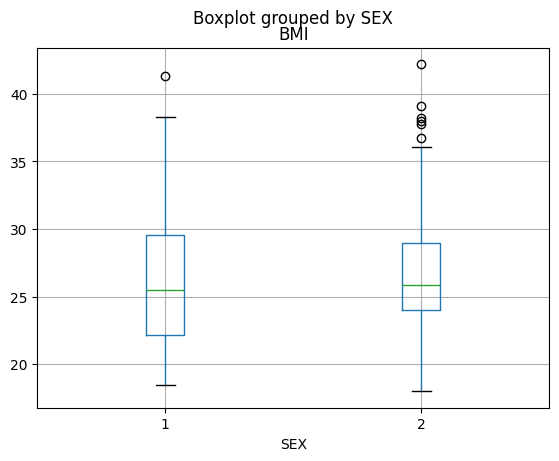

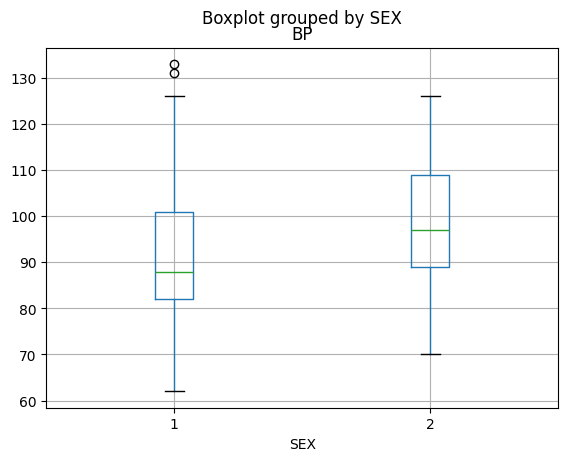

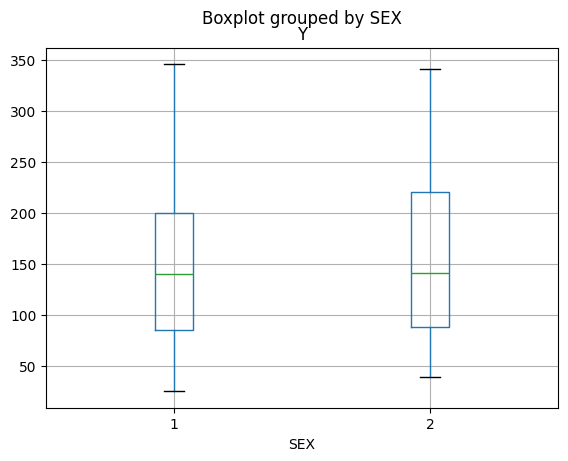

In [5]:
import matplotlib.pyplot as plt

for col in ["BMI", "BP", "Y"]:
    df.boxplot(column=col, by="SEX")
plt.show()

### Task 3: What is the the distribution of Age, Sex, BMI and Y variables?

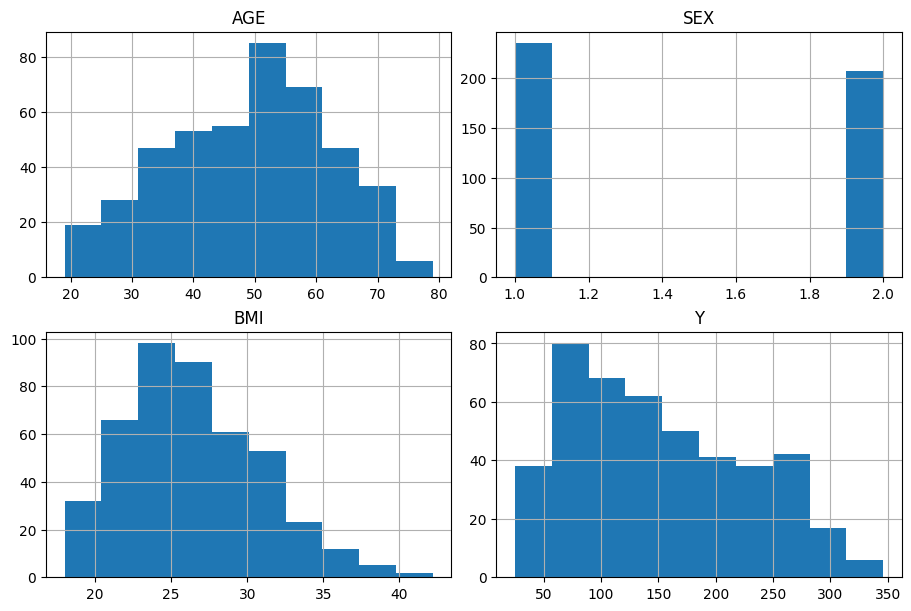

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(9, 6), layout="constrained")

for ax, col in zip(axs.flatten(), ["AGE", "SEX", "BMI", "Y"]):
    ax.hist(df[col])
    ax.set_title(col)
    ax.grid(True)

plt.show()

Conclusions:
- Age: normal distribution
- Sex: uniform distribution
- BMI & Y: hard to tell

### Task 4: Test the correlation between different variables and disease progression (Y)

> **Hint** Correlation matrix would give you the most useful information on which values are dependent.

In [7]:
df.corr()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
AGE,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
SEX,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
BMI,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
BP,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
S1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
S2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
S3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
S4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
S5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
S6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


Checking the last column (Y) from top to bottom we see that:
- Y and BMI have correlation : 0.586
- Y and S5(blood sugar) have correlation : 0.565
- Y and BP have correlation 0.441

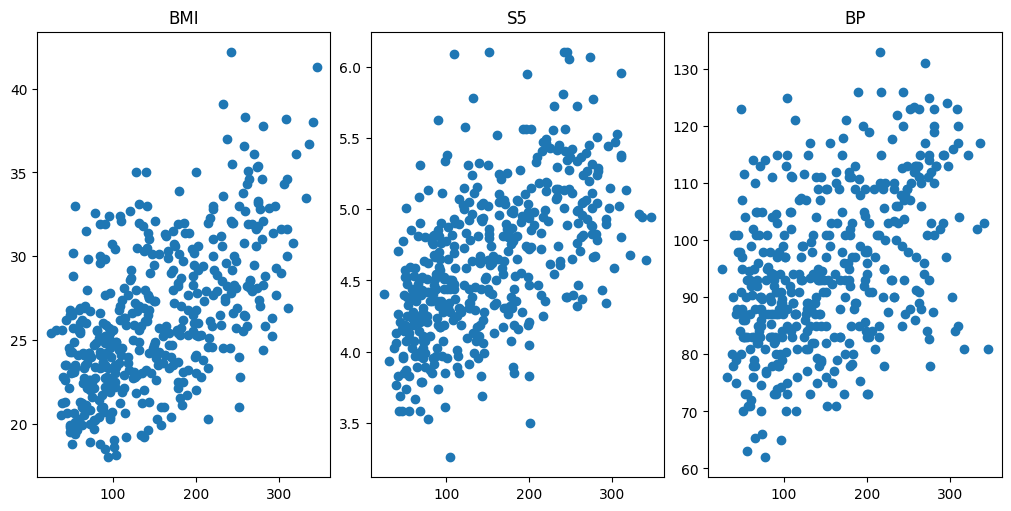

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5), layout="constrained")

for i, n in enumerate(["BMI", "S5", "BP"]):
    ax[i].scatter(df["Y"], df[n])
    ax[i].set_title(n)
plt.show()

### Task 5: Test the hypothesis that the degree of diabetes progression is different between men and women

In [10]:
from scipy.stats import ttest_ind

tval, pval = ttest_ind(
    df.loc[df["SEX"] == 1, ["Y"]],
    df.loc[df["SEX"] == 2, ["Y"]],
    equal_var=False,  # assume that the two samples don't have equal variances
)

print(f"T-value = {tval[0]:.2f}\nP-value: {pval[0]}")

T-value = -0.90
P-value: 0.3674449793083975


**Conclusion**: p-value close to 0 (typically below 0.05) would indicate high confidence in our hypothesis. In our case, there is no strong evidence that sex affects progression of diabetes.